In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
df = pd.read_csv(r"C:\Users\Mauxy Salcedo\OneDrive\mauxy\train.csv", parse_dates=["Date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(1), int64(2)
memory usage: 13.3 MB


In [3]:
resumen_tiendas = df.groupby("Store").agg(
    n_departamentos=("Dept", "nunique"),
    ventas_totales=("Weekly_Sales", "sum"),
    ventas_negativas=("Weekly_Sales", lambda x: (x < 0).sum()),
    ventas_cero=("Weekly_Sales", lambda x: (x == 0).sum()),
).sort_values("ventas_totales", ascending=False)

resumen_tiendas.head(10)

,n_departamentos,ventas_totales,ventas_negativas,ventas_cero
Store,,,,
20,78,3.013978e+08,38,3
4,78,2.995440e+08,5,0
14,77,2.889999e+08,32,3
13,79,2.865177e+08,15,2
2,78,2.753824e+08,22,2
10,77,2.716177e+08,50,5
27,78,2.538559e+08,27,2
6,77,2.237561e+08,21,1
1,77,2.224028e+08,15,3


Selección de tienda para Parte 2 (ML): Se eligió la Tienda 4 porque tiene el segundo mayor volumen de ventas totales (~300M, casi igual a la Tienda 20 que es la 1ª), pero con muchos menos datos problemáticos: solo 5 ventas negativas y 0 en cero de sus 78 departamentos, la más limpia de las tiendas top.

In [4]:
df_tienda4 = df[df["Store"] == 4].copy()
df_tienda4.info()

<class 'pandas.DataFrame'>
RangeIndex: 10272 entries, 29518 to 39789
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         10272 non-null  int64         
 1   Dept          10272 non-null  int64         
 2   Date          10272 non-null  datetime64[us]
 3   Weekly_Sales  10272 non-null  float64       
 4   IsHoliday     10272 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(1), int64(2)
memory usage: 331.2 KB


In [20]:
df_tienda4 = df_tienda4.sort_values(["Dept", "Date"])
df_tienda4["venta_semana_anterior"] = df_tienda4.groupby("Dept")["Weekly_Sales"].shift(1)

df_tienda4[["Dept", "Date", "Weekly_Sales", "venta_semana_anterior"]].head(10)

,Dept,Date,Weekly_Sales,venta_semana_anterior
29518,1,2010-02-05,38724.42,NaN
29519,1,2010-02-12,69872.44,38724.42
29520,1,2010-02-19,49937.09,69872.44
29521,1,2010-02-26,30107.54,49937.09
29522,1,2010-03-05,31580.69,30107.54
29523,1,2010-03-12,29452.49,31580.69
29524,1,2010-03-19,30853.27,29452.49
29525,1,2010-03-26,33401.19,30853.27
29526,1,2010-04-02,75535.18,33401.19
29527,1,2010-04-09,56416.66,75535.18


In [21]:
punto_corte = "2012-06-01"

train = df_tienda4[df_tienda4["Date"] < punto_corte].copy()
test = df_tienda4[df_tienda4["Date"] >= punto_corte].copy()

print("Train:", train.shape)
print("Test:", test.shape)

Train: (8686, 9)
Test: (1586, 9)


In [9]:
train["venta_semana_anterior"].isna().sum()

np.int64(78)

In [10]:
df_tienda4["semana_anio"] = df_tienda4["Date"].dt.isocalendar().week
df_tienda4["mes"] = df_tienda4["Date"].dt.month
df_tienda4["anio"] = df_tienda4["Date"].dt.year

In [11]:
punto_corte = "2012-06-01"

train = df_tienda4[df_tienda4["Date"] < punto_corte].copy()
test = df_tienda4[df_tienda4["Date"] >= punto_corte].copy()

print("Train:", train.shape)
print("Test:", test.shape)

Train: (8686, 9)
Test: (1586, 9)


In [12]:
train = train.dropna(subset=["venta_semana_anterior"])

features = ["Dept", "semana_anio", "mes", "anio", "IsHoliday", "venta_semana_anterior"]

X_train = train[features]
y_train = train["Weekly_Sales"]

X_test = test[features]
y_test = test["Weekly_Sales"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (8608, 6)
X_test: (1586, 6)


In [13]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

print("Modelo entrenado")

Modelo entrenado


In [14]:
pred_rf = modelo_rf.predict(X_test)

error = y_test.values - pred_rf

MAD = np.mean(np.abs(error))
MSE = np.mean(error**2)
RMSE = np.sqrt(MSE)

# MAPE con cuidado: excluir filas donde la venta real es 0 (división por cero)
mask = y_test.values != 0
MAPE = np.mean(np.abs(error[mask] / y_test.values[mask])) * 100

print(f"MAD:  {MAD:,.2f}")
print(f"MSE:  {MSE:,.2f}")
print(f"RMSE: {RMSE:,.2f}")
print(f"MAPE: {MAPE:.2f}%")

MAD:  2,222.58
MSE:  15,604,393.69
RMSE: 3,950.24
MAPE: 2142.34%


In [15]:
y_test.sort_values().head(10)

31913   -0.92
39787    0.04
39780    0.06
39786    0.07
39783    0.08
39779    0.08
39778    0.14
31910    0.25
31911    0.75
31915    0.97
Name: Weekly_Sales, dtype: float64

In [16]:
mask = y_test.values > 10

MAPE = np.mean(np.abs(error[mask] / y_test.values[mask])) * 100

print(f"MAPE (excluyendo ventas < $10): {MAPE:.2f}%")
print(f"Filas excluidas: {(~mask).sum()} de {len(y_test)}")

MAPE (excluyendo ventas < $10): 27.21%
Filas excluidas: 20 de 1586


In [17]:
resultados_test = test.copy()
resultados_test["prediccion"] = pred_rf

comparacion_semanal = resultados_test.groupby("Date").agg(
    ventas_reales=("Weekly_Sales", "sum"),
    ventas_predichas=("prediccion", "sum")
).reset_index()

comparacion_semanal.head(10)

,Date,ventas_reales,ventas_predichas
0,2012-06-01,2179360.94,2.172742e+06
1,2012-06-08,2245257.18,2.175179e+06
2,2012-06-15,2234190.93,2.188661e+06
3,2012-06-22,2197299.65,2.201232e+06
4,2012-06-29,2128362.92,2.189184e+06
5,2012-07-06,2224499.28,2.123100e+06
6,2012-07-13,2100252.61,2.149755e+06
7,2012-07-20,2175563.69,2.090139e+06
8,2012-07-27,2048613.65,2.171338e+06
9,2012-08-03,2174514.13,2.153074e+06


In [18]:
error_semanal = comparacion_semanal["ventas_reales"] - comparacion_semanal["ventas_predichas"]

MAD_semanal = np.mean(np.abs(error_semanal))
MSE_semanal = np.mean(error_semanal**2)
RMSE_semanal = np.sqrt(MSE_semanal)
MAPE_semanal = np.mean(np.abs(error_semanal / comparacion_semanal["ventas_reales"])) * 100

print(f"MAD:  {MAD_semanal:,.2f}")
print(f"MSE:  {MSE_semanal:,.2f}")
print(f"RMSE: {RMSE_semanal:,.2f}")
print(f"MAPE: {MAPE_semanal:.2f}%")

MAD:  56,788.25
MSE:  4,645,294,872.27
RMSE: 68,156.40
MAPE: 2.64%


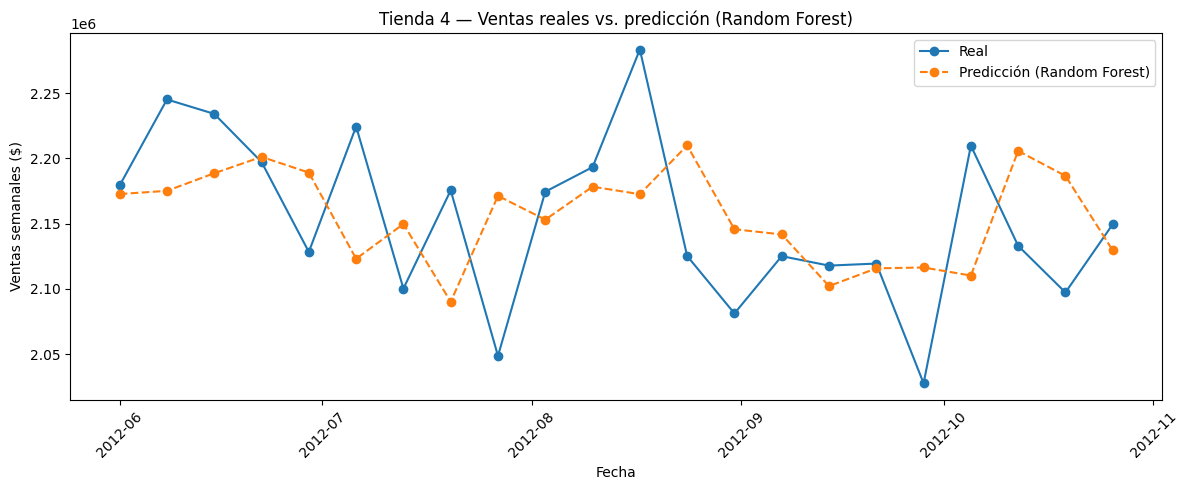

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(comparacion_semanal["Date"], comparacion_semanal["ventas_reales"], label="Real", marker="o")
plt.plot(comparacion_semanal["Date"], comparacion_semanal["ventas_predichas"], label="Predicción (Random Forest)", linestyle="--", marker="o")
plt.title("Tienda 4 — Ventas reales vs. predicción (Random Forest)")
plt.xlabel("Fecha")
plt.ylabel("Ventas semanales ($)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
from sklearn.ensemble import HistGradientBoostingRegressor

modelo_gb = HistGradientBoostingRegressor(random_state=42)
modelo_gb.fit(X_train, y_train)

print("Modelo Gradient Boosting entrenado")

Modelo Gradient Boosting entrenado


In [23]:
pred_gb = modelo_gb.predict(X_test)

error_gb = y_test.values - pred_gb

MAD_gb = np.mean(np.abs(error_gb))
MSE_gb = np.mean(error_gb**2)
RMSE_gb = np.sqrt(MSE_gb)

mask_gb = y_test.values > 10
MAPE_gb = np.mean(np.abs(error_gb[mask_gb] / y_test.values[mask_gb])) * 100

print(f"MAD:  {MAD_gb:,.2f}")
print(f"MSE:  {MSE_gb:,.2f}")
print(f"RMSE: {RMSE_gb:,.2f}")
print(f"MAPE: {MAPE_gb:.2f}%")

MAD:  2,147.28
MSE:  14,105,119.16
RMSE: 3,755.68
MAPE: 54.33%


In [24]:
resultados_test["prediccion_gb"] = pred_gb

comparacion_semanal_gb = resultados_test.groupby("Date").agg(
    ventas_reales=("Weekly_Sales", "sum"),
    ventas_predichas_rf=("prediccion", "sum"),
    ventas_predichas_gb=("prediccion_gb", "sum")
).reset_index()

comparacion_semanal_gb.head(10)

,Date,ventas_reales,ventas_predichas_rf,ventas_predichas_gb
0,2012-06-01,2179360.94,2.172742e+06,2.156939e+06
1,2012-06-08,2245257.18,2.175179e+06,2.163176e+06
2,2012-06-15,2234190.93,2.188661e+06,2.223532e+06
3,2012-06-22,2197299.65,2.201232e+06,2.199462e+06
4,2012-06-29,2128362.92,2.189184e+06,2.177549e+06
5,2012-07-06,2224499.28,2.123100e+06,2.127224e+06
6,2012-07-13,2100252.61,2.149755e+06,2.192272e+06
7,2012-07-20,2175563.69,2.090139e+06,2.089535e+06
8,2012-07-27,2048613.65,2.171338e+06,2.139852e+06
9,2012-08-03,2174514.13,2.153074e+06,2.123958e+06


In [25]:
error_semanal_gb = comparacion_semanal_gb["ventas_reales"] - comparacion_semanal_gb["ventas_predichas_gb"]

MAD_gb_sem = np.mean(np.abs(error_semanal_gb))
MSE_gb_sem = np.mean(error_semanal_gb**2)
RMSE_gb_sem = np.sqrt(MSE_gb_sem)
MAPE_gb_sem = np.mean(np.abs(error_semanal_gb / comparacion_semanal_gb["ventas_reales"])) * 100

print(f"MAD:  {MAD_gb_sem:,.2f}")
print(f"MSE:  {MSE_gb_sem:,.2f}")
print(f"RMSE: {RMSE_gb_sem:,.2f}")
print(f"MAPE: {MAPE_gb_sem:.2f}%")

MAD:  52,525.83
MSE:  3,641,300,274.10
RMSE: 60,343.19
MAPE: 2.45%


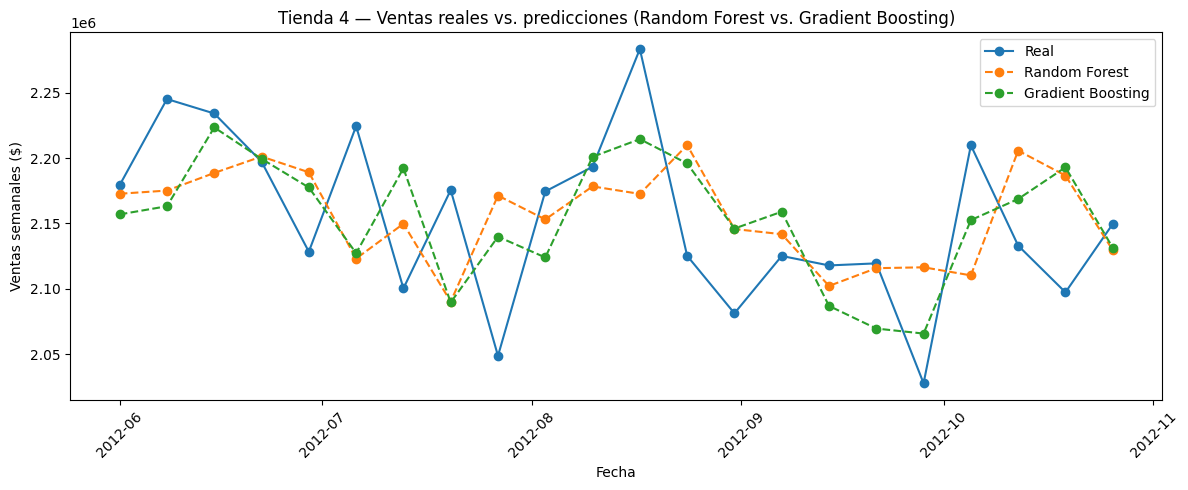

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(comparacion_semanal_gb["Date"], comparacion_semanal_gb["ventas_reales"], label="Real", marker="o")
plt.plot(comparacion_semanal_gb["Date"], comparacion_semanal_gb["ventas_predichas_rf"], label="Random Forest", linestyle="--", marker="o")
plt.plot(comparacion_semanal_gb["Date"], comparacion_semanal_gb["ventas_predichas_gb"], label="Gradient Boosting", linestyle="--", marker="o")
plt.title("Tienda 4 — Ventas reales vs. predicciones (Random Forest vs. Gradient Boosting)")
plt.xlabel("Fecha")
plt.ylabel("Ventas semanales ($)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.inspection import permutation_importance

resultado_importancia = permutation_importance(
    modelo_gb, X_test, y_test, n_repeats=10, random_state=42
)

importancia = pd.DataFrame({
    "variable": X_test.columns,
    "importancia": resultado_importancia.importances_mean
}).sort_values("importancia", ascending=False)

importancia

,variable,importancia
5,venta_semana_anterior,1.873377
0,Dept,0.011287
1,semana_anio,0.002149
4,IsHoliday,0.000600
2,mes,0.000216
3,anio,0.000000


In [28]:
pred_naive = X_test["venta_semana_anterior"].values

error_naive = y_test.values - pred_naive

MAD_naive = np.mean(np.abs(error_naive))
MSE_naive = np.mean(error_naive**2)
RMSE_naive = np.sqrt(MSE_naive)

mask_naive = y_test.values > 10
MAPE_naive = np.mean(np.abs(error_naive[mask_naive] / y_test.values[mask_naive])) * 100

print(f"MAD:  {MAD_naive:,.2f}")
print(f"MSE:  {MSE_naive:,.2f}")
print(f"RMSE: {RMSE_naive:,.2f}")
print(f"MAPE: {MAPE_naive:.2f}%")

MAD:  2,237.98
MSE:  16,324,659.59
RMSE: 4,040.38
MAPE: 17.40%


## 8. Conclusiones — Parte 2 (Machine Learning)

**Metodología:** a diferencia de la Parte 1 (donde se agregaba cada tienda por semana), aquí se trabajó a nivel departamento-semana dentro de una sola tienda (Tienda 4), sin sumar departamentos entre sí. Se usó el mismo punto de corte que la Parte 1 (2012-06-01) para que los resultados fueran comparables. Como features se usaron: `Dept` (categórica), `semana_anio`, `mes`, `anio` (derivadas de la fecha) e `IsHoliday`, más una variable de rezago (`venta_semana_anterior`) calculada por separado para cada departamento para evitar fuga de datos.

Se entrenaron dos modelos: **Random Forest** (100 árboles independientes promediados) y **Gradient Boosting** (árboles entrenados secuencialmente, cada uno corrigiendo los errores del anterior).

**Resultados a nivel tienda** (sumando las predicciones de todos los departamentos por semana, para comparar de forma justa con el Holt-Winters de la Parte 1):

| Modelo | MAD ($) | RMSE ($) | MAPE (%) |
|---|---|---|---|
| Holt-Winters (Parte 1) | 60,118 | 72,338 | 2.82% |
| Random Forest | 56,788 | 68,156 | 2.64% |
| **Gradient Boosting** | **52,526** | **60,343** | **2.45%** |

Hay una mejora consistente en las tres métricas, en el mismo orden (Gradient Boosting < Random Forest < Holt-Winters), lo que sugiere que el Machine Learning sí aporta valor por encima del método estadístico clásico a este nivel de agregación — aunque la ventaja es modesta, no aplastante, algo esperable dado que ambos enfoques comparten la misma limitación de solo ~143 semanas de historia.

**Importancia de variables:** el análisis de `permutation_importance` sobre el Gradient Boosting mostró que `venta_semana_anterior` domina de forma aplastante (importancia ~1.87, contra ~0.011 de la siguiente variable, `Dept`). Variables como `anio` no aportaron nada (importancia 0.000).

**Comparación contra un modelo "ingenuo" (naive):** para evaluar si esa dependencia del rezago era un problema, se comparó el desempeño de los modelos contra simplemente usar `venta_semana_anterior` como predicción directa, sin ningún algoritmo:

| Modelo | MAD ($) | RMSE ($) | MAPE (%) |
|---|---|---|---|
| Naive (copiar semana anterior) | 2,237.98 | 4,040.38 | **17.40%** |
| Random Forest | 2,222.58 | 3,950.24 | 27.21% |
| Gradient Boosting | 2,147.28 | 3,755.68 | 54.33% |

A nivel departamento-semana, los modelos de ML solo mejoran ligeramente al naive en dólares (MAD, RMSE), y en términos porcentuales (MAPE) el naive los supera claramente a ambos. Esto confirma que gran parte del poder predictivo del modelo proviene de la variable de rezago, no de la sofisticación del algoritmo en sí.

**Conclusión general:** el Machine Learning mejora el pronóstico de forma consistente cuando se evalúa a nivel tienda completa, siendo Gradient Boosting el mejor de los tres métodos probados. Sin embargo, a nivel más granular (departamento-semana), su aporte real por encima de un baseline simple es modesto — un hallazgo honesto que resalta la importancia de comparar cualquier modelo contra una base de referencia sencilla antes de asumir que "más complejo" significa "mejor".